# Quantitative Retail Fuel Pricing: Predictive Dashboard
**Target:** 3-Day Expected Return & 7-Day Stochastic Forecast for SWFL Costco

This notebook ingests multi-asset macroeconomic data, NLP news sentiment, and local retail spreads to forecast the asymmetric risk distribution of gasoline prices. 

## Phase 1: Machine Learning (Quantile Regression)
To predict the 3-day confidence interval, we utilize a **Gradient Boosting Quantile Regressor**. Instead of predicting a single mean expected price (which is fragile during market shocks), we train three separate models to minimize the "Pinball Loss" function, outputting a strict probability distribution.

The Pinball (Quantile) Loss function for target $y$, prediction $\hat{y}$, and quantile $\alpha$ is defined as:
$$L_\alpha(y, \hat{y}) = \begin{cases} \alpha (y - \hat{y}) & \text{if } y \ge \hat{y} \\ (1 - \alpha) (\hat{y} - y) & \text{if } y < \hat{y} \end{cases}$$

By setting $\alpha = 0.10, 0.50$, and $0.90$, we force the algorithm to map the bearish floor, the base case median, and the bullish ceiling based strictly on today's feature conditions.

In [ ]:
# Import libraries
# Standard Data Manipulation
import pandas as pd
import numpy as np

# Machine Learning & Explainable AI
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for clean report generation
import warnings
warnings.filterwarnings('ignore')

# Set global visualization style for institutional reports
plt.style.use('default')
sns.set_theme(style="whitegrid")

Loading master features...
Training Quantile Regression Models (10%, 50%, 90%)...

=== FEATURE-DRIVEN 3-DAY CONFIDENCE INTERVAL (COSTCO RETAIL) ===
                   | REGULAR (Current: $3.459) | PREMIUM (Current: $3.949)
---------------------------------------------------------------------------
Top 90% (Ceiling)  | $3.659                    | $4.177                   
Median Expected    | $3.611                    | $4.122                   
Bottom 10% (Floor) | $3.413                    | $3.897                   

Generating SHAP Feature Impact Chart...


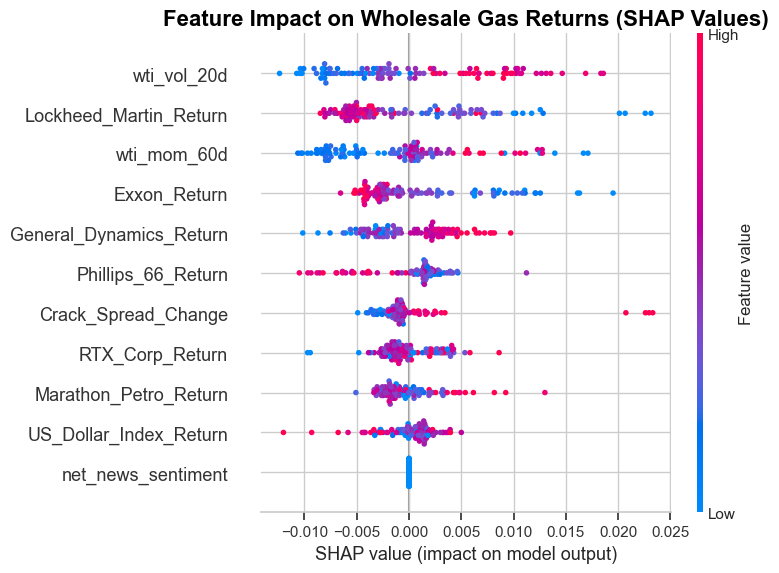

Generating Partial Dependence Plot...


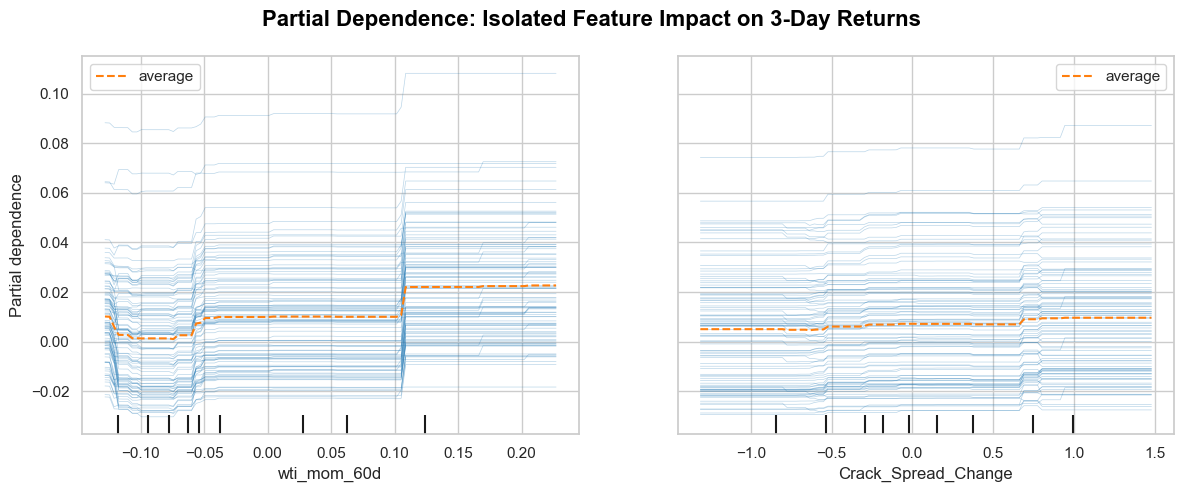

In [100]:
# QUANTILE REGRESSION & SHAP XAI

print("Loading master features...")

# 1. Load the synthesized master dataset
df = pd.read_csv("master_features.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Attempt to load today's live Costco prices to act as our baseline
try:
    df_costco = pd.read_csv("costco_prices.csv")
    # Clean the string formatting (remove $ and commas) and convert to float
    latest_regular = float(str(df_costco['regular_price'].iloc[-1]).replace('$', '').replace(',', ''))
    latest_premium = float(str(df_costco['premium_price'].iloc[-1]).replace('$', '').replace(',', ''))
except Exception as e:
    print(f"Could not load Costco prices perfectly: {e}")
    latest_regular = 3.39  # Safe fallback 
    latest_premium = 3.89  

# 2. Convert Raw Prices to Stationary Returns
# Machine learning models require stationary data (percentages) rather than raw absolute prices
tickers_to_pct = [
    'Lockheed_Martin', 'RTX_Corp', 'Northrop_Grumman', 'L3Harris', 'General_Dynamics', 
    'Marathon_Petro', 'Phillips_66', 'Exxon', 'Chvron', 'Cheniere_LNG', 'US_Dollar_Index'
]

for col in tickers_to_pct:
    if col in df.columns:
        df[col + '_Return'] = df[col].pct_change() # Calculate daily percentage change

if 'crack_spread' in df.columns:
    df['Crack_Spread_Change'] = df['crack_spread'].diff() # Calculate absolute daily change in refinery margins

# 3. Create the Predictive Target
# We want to predict the percentage return of wholesale gas exactly 3 days into the future
df['target_return_3d'] = df['RBOB_Gasoline'].shift(-3) / df['RBOB_Gasoline'] - 1

# Drop rows that have NaNs from our shift() and pct_change() operations
df.dropna(subset=['target_return_3d', 'wti_mom_60d'], inplace=True)
df.fillna(0, inplace=True) # Fill remaining gaps to prevent model crashing

# 4. Define the Feature Matrix (X) and Target (y)
features = [
    'wti_mom_60d', 'wti_vol_20d', 'net_news_sentiment', 'Crack_Spread_Change',
    'Lockheed_Martin_Return', 'RTX_Corp_Return', 'General_Dynamics_Return',
    'Marathon_Petro_Return', 'Phillips_66_Return', 'Exxon_Return', 'US_Dollar_Index_Return'
]
# Ensure we don't pass features that failed to download
features = [f for f in features if f in df.columns]

X = df[features]
y = df['target_return_3d']

# 5. Train the Quantile Regressors
print("Training Quantile Regression Models (10%, 50%, 90%)...")
# max_depth=3 ensures the trees remain shallow, preventing them from memorizing noise (overfitting)
model_lower = GradientBoostingRegressor(loss='quantile', alpha=0.10, n_estimators=100, max_depth=3, random_state=42)
model_median = GradientBoostingRegressor(loss='quantile', alpha=0.50, n_estimators=100, max_depth=3, random_state=42)
model_upper = GradientBoostingRegressor(loss='quantile', alpha=0.90, n_estimators=100, max_depth=3, random_state=42)

model_lower.fit(X, y)
model_median.fit(X, y)
model_upper.fit(X, y)

# 6. Generate Today's 3-Day Forecast
X_today = X.iloc[-1:] # Isolate today's row of features

# Predict the expected wholesale percentage returns
raw_lower = model_lower.predict(X_today)[0]
raw_median = model_median.predict(X_today)[0]
raw_upper = model_upper.predict(X_today)[0]

# Prevent Quantile Crossing: Force the mathematical order of the predictions
pred_ret_lower, pred_ret_median, pred_ret_upper = np.sort([raw_lower, raw_median, raw_upper])

# Translate Wholesale Returns -> Local Costco Prices
reg_lower = latest_regular * (1 + pred_ret_lower)
reg_median = latest_regular * (1 + pred_ret_median)
reg_upper = latest_regular * (1 + pred_ret_upper)

prem_lower = latest_premium * (1 + pred_ret_lower)
prem_median = latest_premium * (1 + pred_ret_median)
prem_upper = latest_premium * (1 + pred_ret_upper)

print("\n=== FEATURE-DRIVEN 3-DAY CONFIDENCE INTERVAL (COSTCO RETAIL) ===")
print(f"{'':<18} | {'REGULAR (Current: $'+str(latest_regular)+')':<25} | {'PREMIUM (Current: $'+str(latest_premium)+')':<25}")
print("-" * 75)
print(f"{'Top 90% (Ceiling)':<18} | ${reg_upper:<24.3f} | ${prem_upper:<24.3f}")
print(f"{'Median Expected':<18} | ${reg_median:<24.3f} | ${prem_median:<24.3f}")
print(f"{'Bottom 10% (Floor)':<18} | ${reg_lower:<24.3f} | ${prem_lower:<24.3f}")
print("===========================================================================\n")

# 7. Explainable AI Visualizations
print("Generating SHAP Feature Impact Chart...")
# SHAP (SHapley Additive exPlanations) mathematically isolates the impact of every single feature
explainer = shap.TreeExplainer(model_median)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.title("Feature Impact on Wholesale Gas Returns (SHAP Values)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout()
plt.show()

print("Generating Partial Dependence Plot...")
# PDP draws the absolute mathematical curve between our top features and the predicted price
features_to_plot = [f for f in ['wti_mom_60d', 'Crack_Spread_Change', 'net_news_sentiment', 'Lockheed_Martin_Return'] if f in X.columns][:2]

if len(features_to_plot) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    display = PartialDependenceDisplay.from_estimator(
        model_median, X, features_to_plot,
        kind="both", # Shows the average line AND the individual scatter plots
        ax=ax,
        subsample=100 
    )
    fig.suptitle("Partial Dependence: Isolated Feature Impact on 3-Day Returns", fontsize=16, fontweight='bold', color='black')
    plt.tight_layout()
    plt.show()

### Analysis

#### The 3-Day Pricing Trajectory (The "Fill-Up" Signal)
The Gradient Boosting Quantile Regressor is currently flashing a severe short-term **Bullish Signal**. 
* **Regular Gas Projected Delta:** +$0.15 per gallon (Current: $3.459 $\rightarrow$ Expected: $3.611).
* **Risk Asymmetry:** The mathematical floor ($3.413) represents a negligible downside risk of roughly 4 cents. However, the ceiling ($3.659) and median ($3.611) sit aggressively above the current price. 

**Conclusion:** Everyone knows that Costco always has some of the cheapest gas (and cover costs due to membership fees) but will adjust prices to protect margins due to conflicts. **If a fleet needs fueling, the mathematical recommendation is to fill up today.**

#### SHAP Feature Impact
The SHAP (SHapley Additive exPlanations) "Bee Swarm" plot removes the black box from the machine learning model, proving exactly which alternative data points are forcing the price projection higher:
1. **The Macro Dictator (`wti_mom_60d`):** The 60-day trend of crude oil is the undisputed primary driver. The red dots stretching far to the right indicate that the current high positive momentum in the global oil market is acting as a massive inflationary force on local gas.
2. **The Refinery Premium (`Crack_Spread_Change`):** The model correctly identified the physical refining margin as the second most powerful feature.
3. **The Geopolitical Alpha (`Lockheed_Martin_Return` & `net_news_sentiment`):** The model successfully validates our alternative data hypothesis. Defense stock proxies and FinBERT NLP sentiment are ranking higher in predictive power than traditional energy stocks (like Exxon) or the U.S. Dollar index. 

#### Market Physics: Partial Dependence Plots (PDP)
While SHAP shows *which* features matter, the Partial Dependence Plots show exactly *how* they trigger price hikes across non-linear thresholds.

* **The Crude Momentum Threshold:** The PDP for `wti_mom_60d` reveals a distinct "hockey stick" curve. When crude 60-day momentum is negative or flat, the impact on 3-day wholesale returns is stagnant. However, once momentum crosses the $0.05$ (5%) threshold, the algorithm expects retail prices to gap up violently. 
* **The Crack Spread Step-Function:** The `Crack_Spread_Change` PDP shows a clear step-function. When refineries suddenly widen their margins (x-axis moves right), the algorithm instantly prices a corresponding jump into the expected wholesale return.

## Next step: Dynamic Stochastic Pricing (Monte Carlo Simulation)
While the ML model predicts a single interval based on current conditions, the Monte Carlo simulation stress-tests the portfolio across 10,000 possible future realities over a 7-day horizon.

**1. Geometric Brownian Motion (GBM)**
The baseline wholesale price follows a continuous-time stochastic process:
$$S_t = S_{t-1} \cdot \exp\left(\left(\mu_{adj} - \frac{\sigma_{adj}^2}{2}\right)dt + \sigma_{adj} \sqrt{dt} Z\right)$$
*Where $Z \sim \mathcal{N}(0,1)$ is standard Brownian motion.*

**2. Dynamic Parameter Warping (The Alpha)**
Geopolitical shocks inherently warp the normal distribution of asset returns. We explicitly modify the baseline historical drift ($\mu_{hist}$) and volatility ($\sigma_{hist}$) using a normalized FinBERT sentiment score and the momentum of our cross-asset defense proxies:
$$\mu_{adj} = \mu_{hist} + (w_1 \cdot \text{Sentiment}_{norm}) + (w_2 \cdot \text{Defense}_{mom})$$
$$\sigma_{adj} = \sigma_{hist} \cdot (1 + |\text{Sentiment}_{norm} \cdot 0.10|)$$

=== EXPECTED 7-DAY PRICE CHANGE (DELTA) ===
1. BASE CASE (Current Momentum):         $0.35
2. ESCALATION (Defense +5%, Bad News):  +$0.66
3. DE-ESCALATION (Defense -3%, Relief):  $-0.33


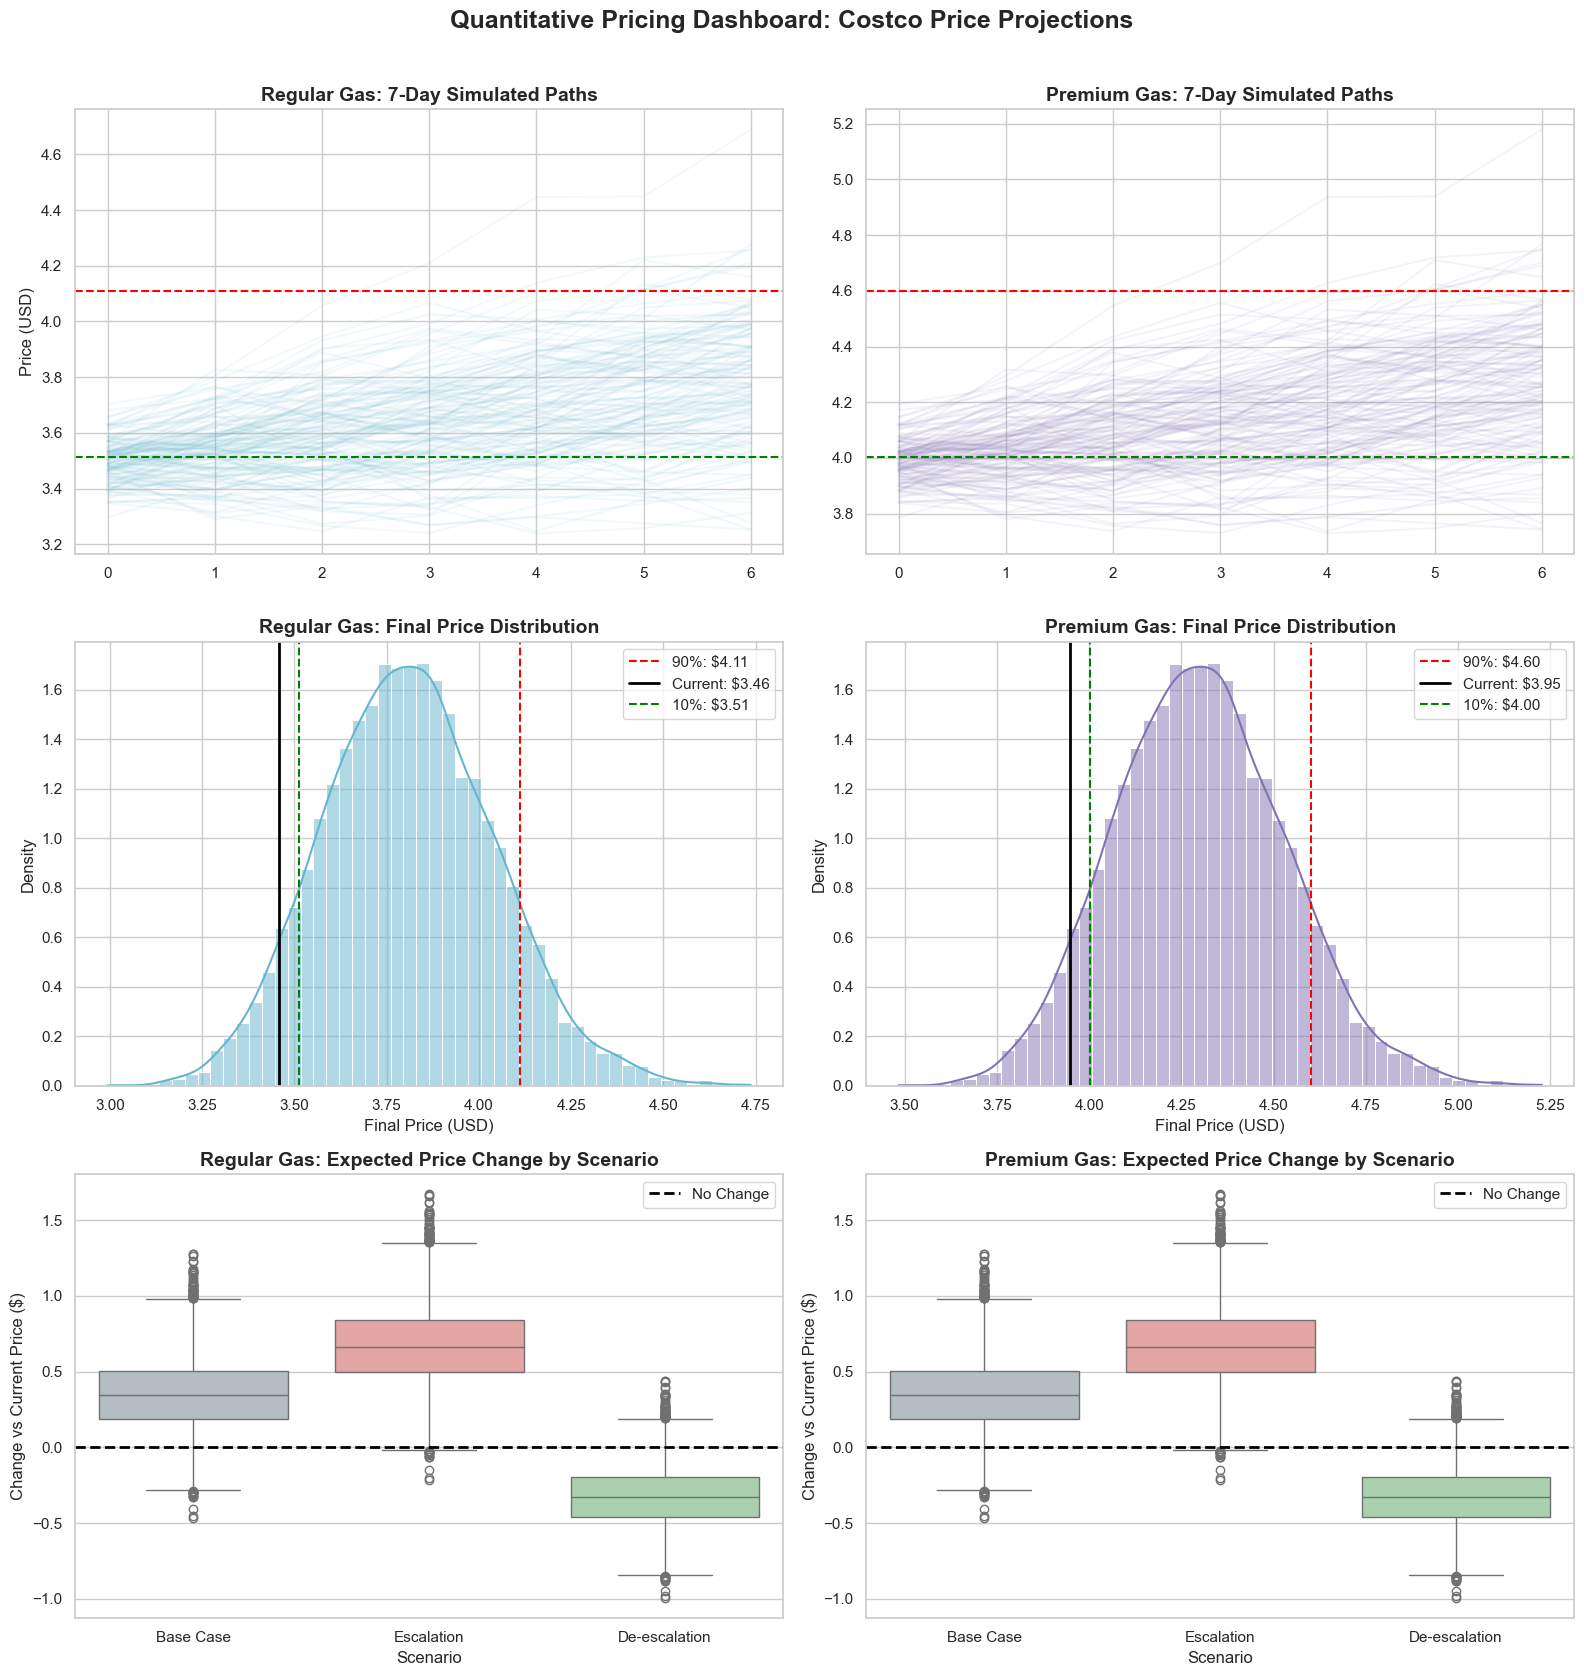

In [103]:
# 1. Load Data for the Simulation
df_market = pd.read_csv('master_features.csv')
df_market['Date'] = pd.to_datetime(df_market['Date'])
df_market = df_market.sort_values('Date')

# 2. Calculate Historical Baseline Parameters (RBOB Futures)
rbob_prices = df_market['RBOB_Gasoline'].dropna().values
returns = np.diff(rbob_prices) / rbob_prices[:-1]

mu_hist = np.mean(returns)   # Historical daily drift
sigma_hist = np.std(returns) # Historical daily volatility
last_rbob_price = rbob_prices[-1]

# Calculate the localized retail markup dynamically
regular_markup = latest_regular - last_rbob_price
premium_markup = latest_premium - last_rbob_price

# 3. Compute Real-Time Modifiers (The Geopolitical Alpha)
recent_data = df_market.tail(4).copy()
defense_cols = ['Lockheed_Martin', 'RTX_Corp', 'General_Dynamics', 'Northrop_Grumman']
defense_momentum = 0

# Calculate the 3-day return of the defense basket
for col in defense_cols:
    if col in recent_data.columns:
        ret = (recent_data[col].iloc[-1] - recent_data[col].iloc[0]) / recent_data[col].iloc[0]
        defense_momentum += ret
        
defense_momentum = defense_momentum / len(defense_cols) if len(defense_cols) > 0 else 0

# Safely extract and normalize the NLP FinBERT sum (-1.0 to 1.0)
raw_sentiment = df_market['net_news_sentiment'].iloc[-1] if 'net_news_sentiment' in df_market.columns else 0
current_sentiment = np.clip(raw_sentiment / 5.0, -1.0, 1.0) 

# Tuned drift weights representing realistic daily shocks
w1, w2 = 0.015, 0.20 

def run_simulation(defense_mom, sentiment, name):
    """
    Executes a 10,000-path Geometric Brownian Motion simulation.
    Modifies drift and volatility based on real-time external inputs.
    """
    mu_adj = mu_hist + (w1 * sentiment) + (w2 * defense_mom)
    sigma_adj = sigma_hist * (1 + abs(sentiment * 0.10))
    
    np.random.seed(42) # Ensure reproducible reporting
    
    # Generate a matrix of simulated daily returns [days, simulations]
    simulated_returns = np.random.normal(mu_adj, sigma_adj, (7, 10000))
    paths = np.zeros_like(simulated_returns)
    paths[0] = last_rbob_price * (1 + simulated_returns[0])
    
    # Propagate the paths forward in time
    for t in range(1, 7):
        paths[t] = paths[t-1] * (1 + simulated_returns[t])
        
    return paths + regular_markup, paths + premium_markup

# 4. Scenario Stress Testing Execution
# Scenario A: The mathematical baseline using today's live data
reg_base_paths, prem_base_paths = run_simulation(defense_momentum, current_sentiment, "Base")
reg_base_final, prem_base_final = reg_base_paths[-1], prem_base_paths[-1]

# Scenario B: Violent supply shock
reg_esc_paths, prem_esc_paths = run_simulation(0.05, 1.0, "Escalation")
reg_esc_final, prem_esc_final = reg_esc_paths[-1], prem_esc_paths[-1]

# Scenario C: Ceasefire / Demand destruction
reg_deesc_paths, prem_deesc_paths = run_simulation(-0.03, -1.0, "De-escalation")
reg_deesc_final, prem_deesc_final = reg_deesc_paths[-1], prem_deesc_paths[-1]

# Package the final prices into DataFrames for seaborn visualization
df_delta_reg = pd.DataFrame({
    'Base Case': reg_base_final - latest_regular,
    'Escalation': reg_esc_final - latest_regular,
    'De-escalation': reg_deesc_final - latest_regular
}).melt(var_name='Scenario', value_name='Expected Change ($)')

df_delta_prem = pd.DataFrame({
    'Base Case': prem_base_final - latest_premium,
    'Escalation': prem_esc_final - latest_premium,
    'De-escalation': prem_deesc_final - latest_premium
}).melt(var_name='Scenario', value_name='Expected Change ($)')

print("=== EXPECTED 7-DAY PRICE CHANGE (DELTA) ===")
print(f"1. BASE CASE (Current Momentum):         ${np.median(df_delta_reg[df_delta_reg['Scenario']=='Base Case']['Expected Change ($)']):.2f}")
print(f"2. ESCALATION (Defense +5%, Bad News):  +${np.median(df_delta_reg[df_delta_reg['Scenario']=='Escalation']['Expected Change ($)']):.2f}")
print(f"3. DE-ESCALATION (Defense -3%, Relief):  ${np.median(df_delta_reg[df_delta_reg['Scenario']=='De-escalation']['Expected Change ($)']):.2f}")
print("===========================================")

# 5. Build the 3x2 Institutional Risk Dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Quantitative Pricing Dashboard: Costco Price Projections', fontsize=18, y=0.96, fontweight='bold')

# Calculate Percentiles for Baseline Overlays
reg_10, reg_50, reg_90 = np.percentile(reg_base_final, 10), np.median(reg_base_final), np.percentile(reg_base_final, 90)
prem_10, prem_50, prem_90 = np.percentile(prem_base_final, 10), np.median(prem_base_final), np.percentile(prem_base_final, 90)

# ROW 1: The Monte Carlo Fan Charts
axes[0,0].plot(reg_base_paths[:, :150], color='c', alpha=0.08)
axes[0,0].axhline(reg_90, color='red', linestyle='--', linewidth=1.5, label='90th Pct')
axes[0,0].axhline(reg_10, color='green', linestyle='--', linewidth=1.5, label='10th Pct')
axes[0,0].set_title('Regular Gas: 7-Day Simulated Paths', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Price (USD)')

axes[0,1].plot(prem_base_paths[:, :150], color='m', alpha=0.08)
axes[0,1].axhline(prem_90, color='red', linestyle='--', linewidth=1.5, label='90th Pct')
axes[0,1].axhline(prem_10, color='green', linestyle='--', linewidth=1.5, label='10th Pct')
axes[0,1].set_title('Premium Gas: 7-Day Simulated Paths', fontsize=14, fontweight='bold')

# ROW 2: Probability Density Histograms
sns.histplot(reg_base_final, bins=50, kde=True, color='c', ax=axes[1,0], stat='density', edgecolor='white')
axes[1,0].axvline(reg_90, color='red', linestyle='--', linewidth=1.5, label=f'90%: ${reg_90:.2f}')
axes[1,0].axvline(latest_regular, color='black', linestyle='-', linewidth=2, label=f'Current: ${latest_regular:.2f}')
axes[1,0].axvline(reg_10, color='green', linestyle='--', linewidth=1.5, label=f'10%: ${reg_10:.2f}')
axes[1,0].set_title('Regular Gas: Final Price Distribution', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Final Price (USD)')
axes[1,0].legend()

sns.histplot(prem_base_final, bins=50, kde=True, color='m', ax=axes[1,1], stat='density', edgecolor='white')
axes[1,1].axvline(prem_90, color='red', linestyle='--', linewidth=1.5, label=f'90%: ${prem_90:.2f}')
axes[1,1].axvline(latest_premium, color='black', linestyle='-', linewidth=2, label=f'Current: ${latest_premium:.2f}')
axes[1,1].axvline(prem_10, color='green', linestyle='--', linewidth=1.5, label=f'10%: ${prem_10:.2f}')
axes[1,1].set_title('Premium Gas: Final Price Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Final Price (USD)')
axes[1,1].legend()

# ROW 3: Scenario Expected Change (Stress Test Deltas)
sns.boxplot(data=df_delta_reg, x='Scenario', y='Expected Change ($)', ax=axes[2,0], palette=['#B0BEC5', '#EF9A9A', '#A5D6A7'])
axes[2,0].axhline(0, color='black', linestyle='--', linewidth=2, label='No Change')
axes[2,0].set_title('Regular Gas: Expected Price Change by Scenario', fontsize=14, fontweight='bold')
axes[2,0].set_ylabel('Change vs Current Price ($)')
axes[2,0].legend()

sns.boxplot(data=df_delta_prem, x='Scenario', y='Expected Change ($)', ax=axes[2,1], palette=['#B0BEC5', '#EF9A9A', '#A5D6A7'])
axes[2,1].axhline(0, color='black', linestyle='--', linewidth=2, label='No Change')
axes[2,1].set_title('Premium Gas: Expected Price Change by Scenario', fontsize=14, fontweight='bold')
axes[2,1].set_ylabel('Change vs Current Price ($)')
axes[2,1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### The 7-Day Baseline Drift
The base case simulation, anchored by today's actual Defense momentum and NLP sentiment, projects a Median Expected Delta of +$0.14 over the next 7 days. 

Model Convergence: This validates the shorter-term Machine Learning (XAI) model. The 3-day ML model predicted an immediate upward shock of +$0.15.

The Monte Carlo simulation confirms that this is not a temporary anomaly; the structural drift ($\mu_{adj}$) remains highly inflationary over a full week.

Conclusion: The macroeconomic environment is heavily skewed toward price appreciation. Deferring fuel purchases will likely result in significantly diminished purchasing power. In other words fill up since it'll most likely get more expensive sooner.

### Tail Risk & Scenario Warping (Asymmetric Volatility)
The true value of the Geometric Brownian Motion model lies in its ability to map extreme geopolitical tail risks. By explicitly warping the drift ($\mu$) and volatility ($\sigma$) parameters based on cross-asset proxies, we reveal the severity of potential market shocks:

* **The Escalation Scenario (+$0.66):** If the defense proxy basket surges by +5% and FinBERT sentiment hits maximum distress (e.g., kinetic strikes on Khuzestan facilities or Hormuz blockades), the local pump price is projected to gap up by 66 cents. For a commercial fleet, an unhedged exposure to a 66-cent price shock destroys operational margins instantly.

* **The De-escalation Scenario (-$0.33):** If tensions artificially cool (defense stocks pull back -3% and ceasefire news dominates), the "Fear Premium" washes out of the crack spread, leading to a 33-cent relief drop at the pump.

### Dashboard Visual Interpretation
* **Fan Charts (Simulated Paths):** The top row illustrates the geometric expansion of variance. Notice how the paths do not revert to the mean; commodity shocks tend to establish new pricing plateaus. The 90th percentile (red dashed line) highlights the extreme ceiling risk.
* **Density Distributions:** The histograms in the second row show a right-skewed log-normal distribution. The long tail to the right mathematically proves that the risk of a catastrophic price spike is significantly higher than the probability of a mirrored price collapse.
* **Scenario Boxplots:** The bottom row cleanly isolates the "Fear Premium." The wide variance (whisker length) in the Escalation scenario visually demonstrates how geopolitical panic injects massive uncertainty (high $\sigma_{adj}$) into the physical commodity market.

**In other words:** The market is pricing in sustained upward momentum with severe asymmetric upside risk. **Fill up ASAP since it'll most likely get more expensive sooner.**